## Use ind. network maps for gradient network dispersion measures

1. Within/between network distance of vis2


In [3]:
import numpy as np
import pandas as pd
import nibabel as nib
import seaborn as sns
import matplotlib.pyplot as plt
import hcp_utils as hcp
from matplotlib.colors import ListedColormap
import seaborn as sns
import os.path as op

bids_folder ='/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'
subList = [f'{i:02d}' for i in range(1, 67)]
subArray = np.array([i for i in range(1, 67)])

grad_folder = op.join(bids_folder, 'derivatives', 'gradients.36Pscrub3BPfilterrunFD104')
net_folder = op.join(bids_folder, 'derivatives', 'networks_infomap_full_01')

from numrisk.fmri_analysis.gradients.utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()

# add group info
df_participants = pd.read_csv(op.join('/mnt_03/ds-dnumrisk' , 'add_tables','subjects_recruit_scan_scanned-final.csv'), header=0) #, index_col=0
group_list = df_participants.loc[:,['subject ID','group']].rename(mapper={'subject ID': 'subject'},axis=1).dropna().astype({'subject': int, 'group': int}).set_index('subject')
group_list = group_list#.reset_index()

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


251002-12:31:19,809 nipype.utils WARNING:
	 A newer version (1.10.0) of nipy/nipype is available. You are using 1.8.6
[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


### 1. Within/between network distance of vis2


In [6]:
from numrisk.fmri_analysis.gradients.utils import get_glasser_parcels, get_glasser_CAatlas_mapping
mask_glasser, labeling_glasser = get_glasser_parcels(space = 'fsaverage5' )
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

from brainspace.utils.parcellation import map_to_labels
caNets_fsav5_mapping = map_to_labels(glasser_CAatlas_mapping['ca_network'].values , labeling_glasser, mask=mask_glasser) #, fill=np.nan) #grad_sub[n_grad-1]

In [15]:
gms.shape

(10, 20484)

In [82]:
n_net_source = 2 # visual2
n_net_target = 5 #dorsal attention

n_grad = 2

df = pd.DataFrame(columns=['subject', 
                           'cent_source_ind', 'cent_target_ind',
                           'cent_source_ca', 'cent_target_ca',
                           'within_disp_source_ind', 'within_disp_source_ca',])
for sub in subList:
    try:
        gms = np.load(op.join(grad_folder, f'sub-{sub}', f'sub-{sub}_g-aligned_space-fsaverag5_n10.npy'))
        nets = np.load(op.join(net_folder, f'sub-{sub}_consensusMapping_confspec-36Pscrub3BPfilter.npy'))

        nets_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
        nets_fsav5[mask] = nets

        netNodes_indices_source = np.where(nets_fsav5 == (n_net_source))[0]
        netNodes_indices_target = np.where(nets_fsav5 == (n_net_target))[0]
            
        gm = gms[n_grad - 1, :]
        gm_net_source_loadings = gm[netNodes_indices_source]
        gm_net_target_loadings = gm[netNodes_indices_target]
        centroid_source_ind = np.nanmean(gm_net_source_loadings)
        centroid_target_ind = np.nanmean(gm_net_target_loadings)
        within_disp_source_ind = np.nanmean(np.abs(gm_net_source_loadings - centroid_source_ind))
        
        # caNets
        centroid_source_ca = np.nanmean(gm[np.where(caNets_fsav5_mapping == (n_net_source))[0]])
        centroid_target_ca = np.nanmean(gm[np.where(caNets_fsav5_mapping == (n_net_target))[0]])
        within_disp_source_ca = np.nanmean(np.abs(gm[np.where(caNets_fsav5_mapping == (n_net_source))[0]] - centroid_source_ca))
        
        df = pd.concat([df, pd.DataFrame({'subject': [int(sub)], 'cent_source_ind': [centroid_source_ind], 'cent_target_ind': [centroid_target_ind],
                                           'cent_source_ca': [centroid_source_ca], 'cent_target_ca': [centroid_target_ca],
                                           'within_disp_source_ind': [within_disp_source_ind], 'within_disp_source_ca': [within_disp_source_ca]})], ignore_index=True)
        #print("sub-"+ sub + " done")

    except Exception as e:
        print("sub-"+ sub + " failed")

df.set_index('subject', inplace=True)
df = df.join(group_list, on='subject', how='inner')


/tmp/ipykernel_2151666/483220499.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame({'subject': [int(sub)], 'cent_source_ind': [centroid_source_ind], 'cent_target_ind': [centroid_target_ind],


sub-02 failed


In [83]:

df['nets_distance_ind'] = np.abs(df['cent_target_ind'] - df['cent_source_ind'])
df['nets_distance_ca'] = np.abs(df['cent_target_ca'] - df['cent_source_ca'])



nets_distance_ca - not normal distribution (reject H0)
MannwhitneyuResult(statistic=320.0, pvalue=0.006474467707553201)


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 15.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


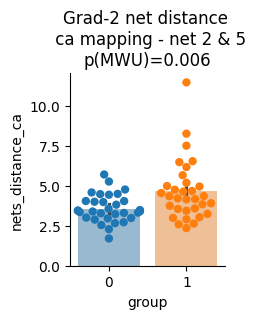

In [85]:
from scipy.stats import normaltest, ttest_ind, mannwhitneyu
alpha = 0.05

mapping_kind = 'ca' # 'ca' #. 
y_var =  f'nets_distance_{mapping_kind}' #'grad_minmaxdiff' #

tmp = df.set_index('group', append=True).dropna(subset=[y_var])

figure, axes = plt.subplots(1, 1,figsize = (2,2.5))
sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y=y_var, alpha=0.5,legend=False)
sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=6,legend=False)
_, pval_normal = normaltest(tmp[y_var])
if pval_normal > alpha:
        test_name = 'TTest'
        print(f'{y_var} - normal distribution (fail to reject H0)')
        stats = ttest_ind(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0, equal_var=False)
else: # non parametric test
        test_name = 'MWU'
        print(f'{y_var} - not normal distribution (reject H0)')    
        stats = mannwhitneyu(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0)
axes.set(title=f'Grad-{n_grad} net distance \n {mapping_kind} mapping - net {n_net_source} & {n_net_target}\np({test_name})={stats.pvalue:.3f}',
    ylabel=y_var, xlabel='group')#,ylim=[0,15])
sns.despine()
print(stats)

<Axes: xlabel='cent_target_ca', ylabel='Density'>

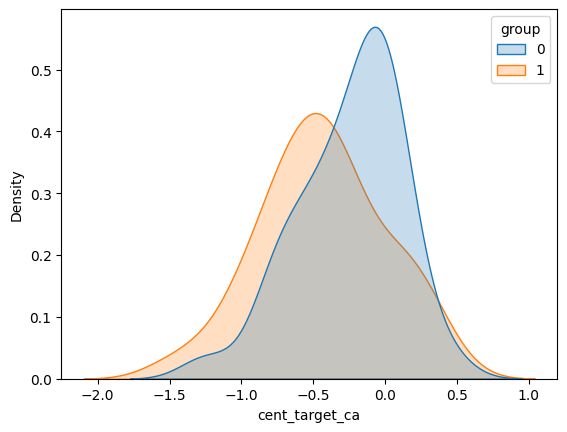

In [77]:
sns.kdeplot(data=tmp.reset_index(), x='cent_target_ca', hue='group', fill=True)

cent_source_ind - not normal distribution (reject H0)
MannwhitneyuResult(statistic=361.0, pvalue=0.02890748234397526)


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 9.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


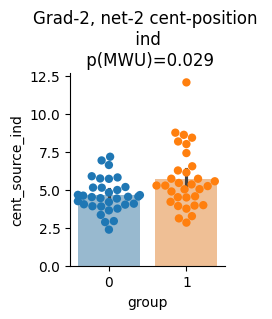

In [81]:
mapping_kind = 'ind' # 'ca' #. 
y_var = f'cent_source_{mapping_kind}' #'within_disp_source_ca' # 'cent_source_ind' #'cent_source_ca' # 'nets_distance_ind' #'nets_distance_ca' #

tmp = df.set_index('group', append=True).dropna(subset=[y_var])

figure, axes = plt.subplots(1, 1,figsize = (2,2.5))
sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y=y_var, alpha=0.5,legend=False)
sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=6,legend=False)
_, pval_normal = normaltest(tmp[y_var])
if pval_normal > alpha:
        test_name = 'TTest'
        print(f'{y_var} - normal distribution (fail to reject H0)')
        stats = ttest_ind(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0, equal_var=False)
else: # non parametric test
        test_name = 'MWU'
        print(f'{y_var} - not normal distribution (reject H0)')    
        stats = mannwhitneyu(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0)
axes.set(title=f'Grad-{n_grad}, net-{n_net_source} cent-position \n {mapping_kind} \n p({test_name})={stats.pvalue:.3f}',
    ylabel=y_var, xlabel='group')#,ylim=[0,15])
sns.despine()
print(stats)

within_disp_source_ca - not normal distribution (reject H0)
MannwhitneyuResult(statistic=345.0, pvalue=0.016634356429668276)


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 15.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 6.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


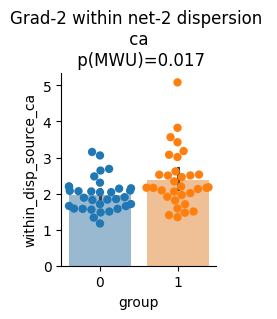

In [73]:
mapping_kind = 'ca' # 'ca' #. 
y_var = f'within_disp_source_{mapping_kind}' #'within_disp_source_ca' # 'cent_source_ind' #'cent_source_ca' # 'nets_distance_ind' #'nets_distance_ca' #

tmp = df.set_index('group', append=True).dropna(subset=[y_var])

figure, axes = plt.subplots(1, 1,figsize = (2,2.5))
sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y=y_var, alpha=0.5,legend=False)
sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=6,legend=False)
_, pval_normal = normaltest(tmp[y_var])
if pval_normal > alpha:
        test_name = 'TTest'
        print(f'{y_var} - normal distribution (fail to reject H0)')
        stats = ttest_ind(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0, equal_var=False)
else: # non parametric test
        test_name = 'MWU'
        print(f'{y_var} - not normal distribution (reject H0)')    
        stats = mannwhitneyu(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0)
axes.set(title=f'Grad-{n_grad} within net-{n_net_source} dispersion \n {mapping_kind} \n p({test_name})={stats.pvalue:.3f}',
    ylabel=y_var, xlabel='group')#,ylim=[0,15])
sns.despine()
print(stats)

In [55]:
tmp.sort_values(by=['group', y_var], ascending=[False, False])

,,cent_source_ind,cent_target_ind,cent_source_ca,cent_target_ca,nets_distance_ind,nets_distance_ca
subject,group,,,,,,
46,1,12.071000,-0.680575,10.790251,-1.450060,12.751575,12.240311
39,1,8.618649,0.142496,8.594237,-0.294484,8.476153,8.888721
27,1,8.429267,-0.986888,7.974458,-0.564121,9.416155,8.538579
40,1,8.180569,-1.025428,6.893227,-1.040013,9.205997,7.933240
45,1,8.008095,-0.615800,7.178754,-0.594106,8.623896,7.772860
...,...,...,...,...,...,...,...
3,0,2.939419,0.478343,3.297894,0.032773,2.461076,3.265121
55,0,4.520590,0.696014,3.356255,0.100080,3.824576,3.256175
66,0,3.644314,-0.758488,2.999119,-0.063809,4.402802,3.062928


<Axes: xlabel='cent_source_ca', ylabel='Density'>

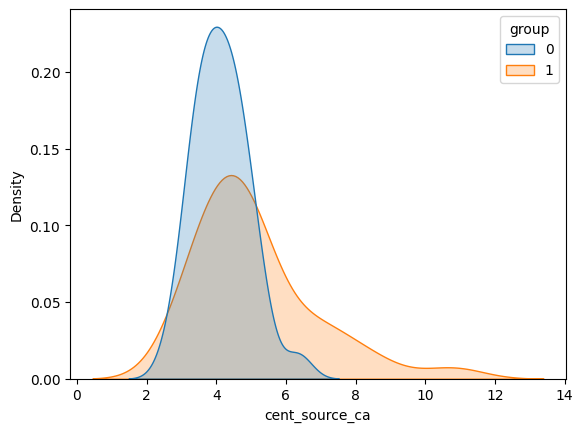

## Are these specific parts of the networks that can be close or far?

In [87]:
N_vertices = 20484

In [ ]:
## plot indices as magnitude on surface
from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt 
import matplotlib.pyplot as plt

hemi_to_plot = 'R'
fsaverage = fetch_surf_fsaverage('fsaverage5') 
views = ['medial','lateral','dorsal','posterior']
cmap = 'viridis' # 

i_hemi_to_plot = 0 if hemi_to_plot == 'L' else 1  
map_fsav5_hemi = np.split(np.arange(N_vertices),2)[i_hemi_to_plot]

surf_mesh = fsaverage.infl_right if hemi_to_plot =='R' else fsaverage.infl_left
bg_map = fsaverage.sulc_right if hemi_to_plot =='R' else fsaverage.sulc_left

figure, axes = plt.subplots(nrows=1, ncols=len(views),figsize = (15,8), subplot_kw=dict(projection='3d'))
for i,view in enumerate(views):
    colbar = True if view == 'posterior' else False
    nplt.plot_surf(surf_mesh=surf_mesh , surf_map= map_fsav5_hemi, avg_method = 'median',# infl_right # pial_right
            view= view,cmap=cmap, colorbar=colbar, #title=f'sub-{sub}, grad {n_grad+1}',
            #vmin = 0, vmax=12,
            bg_map=bg_map, bg_on_data=True,darkness=0.7, axes=axes[i]) 
figure.subplots_adjust(wspace=0.01)

In [ ]:
#import matplotlib.patches as mpatches
#import hcp_utils as hcp
#from matplotlib.colors import ListedColormap